# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [3]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "./src")


## 2. 데이터 로드

In [1]:
import sys

sys.modules.pop("data", None)
sys.path.insert(0, r"C:\github\jungle\ai\mnist-lab\src")

In [2]:
import os, sys
print(os.getcwd())
print(sys.path[:5])

import data
print(data)
print(getattr(data, "__file__", "no file"))

C:\github\jungle\ai\mnist-lab
['C:\\github\\jungle\\ai\\mnist-lab\\src', 'C:\\github\\jungle\\ai\\mnist-lab', 'C:\\Users\\user\\anaconda3\\python312.zip', 'C:\\Users\\user\\anaconda3\\DLLs', 'C:\\Users\\user\\anaconda3\\Lib']
<module 'data' from 'C:\\github\\jungle\\ai\\mnist-lab\\src\\data.py'>
C:\github\jungle\ai\mnist-lab\src\data.py


In [3]:
from data import load_mnist

(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test: (10000, 784) (10000,)


## 3. 구현 및 테스트 통과 확인

`src/` 아래 역할별 파일의 **TODO**를 순서대로 구현한 뒤 아래 셀을 실행하세요.
- 주요 구현 파일: `activations.py`, `layers.py`, `losses.py`, `optimizers.py`, `network.py`, `training.py`
- 구현 파일은 역할별 모듈을 직접 import합니다. 예: `from network import NeuralNetwork`
- 개발 순서: 과제 안내문 참조
- 테스트: `tests/` 아래의 단계별 단위 테스트를 필요한 파일부터 실행합니다. 처음에는 전체 테스트보다 맡은 부분의 테스트 파일을 먼저 실행하세요.
    - ReLU만 확인: `TEST_TARGET = "tests/test_relu.py"`
    - 파일 안의 일부 테스트만 확인: `PYTEST_KEYWORD = "backward"`
    - 전체 테스트 확인: `TEST_TARGET = "tests/"`

In [4]:
import subprocess
import sys
from pathlib import Path

# Colab/로컬 모두 현재 노트북 실행 위치를 저장소 루트로 사용합니다.
repo_dir = Path.cwd()

# 처음에는 자신이 구현 중인 부분의 테스트 파일만 실행하세요.
# 예: tests/test_relu.py, tests/test_affine.py, tests/test_training.py
TEST_TARGET = "tests/"

# 특정 이름이 들어간 테스트만 실행하고 싶을 때 사용합니다.
# 예: "backward". 전체 파일을 실행하려면 빈 문자열로 둡니다.
PYTEST_KEYWORD = ""

cmd = [sys.executable, "-m", "pytest", TEST_TARGET, "-v"]
if PYTEST_KEYWORD:
    cmd.extend(["-k", PYTEST_KEYWORD])

print("실행 경로:", repo_dir)
print("실행 명령:", " ".join(cmd))
result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(repo_dir)
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode == 0:
    print("\n선택한 테스트를 통과했습니다.")
else:
    print("\n선택한 테스트 중 실패가 있습니다.")


실행 경로: C:\github\jungle\ai\mnist-lab
실행 명령: C:\Users\user\anaconda3\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-8.4.2, pluggy-1.6.0 -- C:\Users\user\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\github\jungle\ai\mnist-lab
plugins: anyio-4.9.0, langsmith-0.3.45
collecting ... collected 21 items

tests/test_adam.py::TestAdam::test_adam_update_changes_params PASSED     [  4%]
tests/test_affine.py::TestAffine::test_affine_forward_shape PASSED       [  9%]
tests/test_affine.py::TestAffine::test_affine_backward_grad_shape PASSED [ 14%]
tests/test_batchnorm.py::TestBatchNorm::test_batchnorm_forward_shape PASSED [ 19%]
tests/test_batchnorm.py::TestBatchNorm::test_batchnorm_backward_shape PASSED [ 23%]
tests/test_cross_entropy_loss.py::TestCrossEntropyLoss::test_cross_entropy_loss_scalar PASSED [ 28%]
tests/test_cross_entropy_loss.py::TestCrossEntropyLoss::test_cross_entropy_los

## 4. 모델·옵티마이저 생성 및 학습

In [ ]:
from network import NeuralNetwork
from optimizers import Adam
from training import train

model = NeuralNetwork(use_batchnorm=True, use_dropout=True)  # BatchNorm, Dropout 필수
optimizer = Adam(lr=0.001)

loss_history = train(model, optimizer, x_train, y_train, epochs=40, batch_size=128)

## 5. 평가 및 손실 커브

In [ ]:
from training import evaluate, plot_loss_history

acc, n_params = evaluate(model, x_test, y_test)
print(f'Test Accuracy: {acc:.2f}%')
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)

## 4. 모델·옵티마이저 생성 및 학습

In [8]:
from network import NeuralNetwork
from optimizers import Adam, SGD
from training import train
import time

def run_train(name, model, optimizer, epochs, batch_size):
    start = time.time()
    loss_history = train(model, optimizer, x_train, y_train, epochs=epochs, batch_size=batch_size)
    sec = time.time() - start
    print(f"{name} | epochs={epochs} | batch={batch_size} | time={sec:.2f}s | final_loss={loss_history[-1]:.4f}")
    return loss_history, sec


# ============================================================
# 1. Batch Size 비교
# lr, optimizer, epoch는 같게 두고 batch_size만 변경
# ============================================================

model_batch_10 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_10 = Adam(lr=0.001)
loss_batch_10, time_batch_10 = run_train("batch_10", model_batch_10, optimizer_batch_10, epochs=20, batch_size=10)

model_batch_128 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_128 = Adam(lr=0.001)
loss_batch_128, time_batch_128 = run_train("batch_128", model_batch_128, optimizer_batch_128, epochs=20, batch_size=128)

model_batch_60000 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_60000 = Adam(lr=0.001)
loss_batch_60000, time_batch_60000 = run_train("batch_60000", model_batch_60000, optimizer_batch_60000, epochs=20, batch_size=60000)


# ============================================================
# 2. Learning Rate 비교
# batch_size, optimizer, epoch는 같게 두고 lr만 변경
# lr=100, lr=0.1은 너무 큰 학습률이 어떤 문제를 만드는지 보기 위한 실험
# ============================================================

model_lr_100 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_100 = Adam(lr=100)
loss_lr_100, time_lr_100 = run_train("lr_100", model_lr_100, optimizer_lr_100, epochs=20, batch_size=128)

model_lr_0_1 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_1 = Adam(lr=0.1)
loss_lr_0_1, time_lr_0_1 = run_train("lr_0.1", model_lr_0_1, optimizer_lr_0_1, epochs=20, batch_size=128)

model_lr_0_001 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_001 = Adam(lr=0.001)
loss_lr_0_001, time_lr_0_001 = run_train("lr_0.001", model_lr_0_001, optimizer_lr_0_001, epochs=20, batch_size=128)

model_lr_0_00001 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_00001 = Adam(lr=0.00001)
loss_lr_0_00001, time_lr_0_00001 = run_train("lr_0.00001", model_lr_0_00001, optimizer_lr_0_00001, epochs=20, batch_size=128)


# ============================================================
# 3. Dropout 비교
# lr, batch_size, optimizer는 같게 두고 dropout 사용 여부만 변경
# ============================================================

model_dropout_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_dropout_on = Adam(lr=0.001)
loss_dropout_on, time_dropout_on = run_train("dropout_on", model_dropout_on, optimizer_dropout_on, epochs=100, batch_size=128)

model_dropout_off = NeuralNetwork(use_batchnorm=True, use_dropout=False)
optimizer_dropout_off = Adam(lr=0.001)
loss_dropout_off, time_dropout_off = run_train("dropout_off", model_dropout_off, optimizer_dropout_off, epochs=100, batch_size=128)


# ============================================================
# 4. Optimizer 비교
# lr, batch_size, epoch는 같게 두고 Adam과 SGD 비교
# ============================================================

model_optimizer_adam = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_adam = Adam(lr=0.001)
loss_optimizer_adam, time_optimizer_adam = run_train("optimizer_adam", model_optimizer_adam, optimizer_adam, epochs=20, batch_size=128)

model_optimizer_sgd = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_sgd = SGD(lr=0.001)
loss_optimizer_sgd, time_optimizer_sgd = run_train("optimizer_sgd", model_optimizer_sgd, optimizer_sgd, epochs=20, batch_size=128)


# ============================================================
# 5. BatchNorm 비교
# lr, batch_size, optimizer는 같게 두고 batchnorm 사용 여부만 변경
# ============================================================

model_batchnorm_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batchnorm_on = Adam(lr=0.001)
loss_batchnorm_on, time_batchnorm_on = run_train("batchnorm_on", model_batchnorm_on, optimizer_batchnorm_on, epochs=20, batch_size=128)

model_batchnorm_off = NeuralNetwork(use_batchnorm=False, use_dropout=True)
optimizer_batchnorm_off = Adam(lr=0.001)
loss_batchnorm_off, time_batchnorm_off = run_train("batchnorm_off", model_batchnorm_off, optimizer_batchnorm_off, epochs=20, batch_size=128)

Epoch 1/10  loss: 0.7024
Epoch 2/10  loss: 0.5166
Epoch 3/10  loss: 0.4635
Epoch 4/10  loss: 0.4328
Epoch 5/10  loss: 0.4145
Epoch 6/10  loss: 0.4025
Epoch 7/10  loss: 0.3992
Epoch 8/10  loss: 0.3834
Epoch 9/10  loss: 0.3789
Epoch 10/10  loss: 0.3728
model1_1 | epochs=10 | batch=10 | time=978.54s | final_loss=0.3728
Epoch 1/10  loss: 1.0089
Epoch 2/10  loss: 0.6103
Epoch 3/10  loss: 0.4922
Epoch 4/10  loss: 0.4182
Epoch 5/10  loss: 0.3699
Epoch 6/10  loss: 0.3293
Epoch 7/10  loss: 0.3055
Epoch 8/10  loss: 0.2828
Epoch 9/10  loss: 0.2619
Epoch 10/10  loss: 0.2491
model1_2 | epochs=10 | batch=128 | time=95.85s | final_loss=0.2491
Epoch 1/10  loss: 2.4150
Epoch 2/10  loss: 2.1547
Epoch 3/10  loss: 1.9188
Epoch 4/10  loss: 1.7216
Epoch 5/10  loss: 1.5642
Epoch 6/10  loss: 1.4324
Epoch 7/10  loss: 1.3330
Epoch 8/10  loss: 1.2517
Epoch 9/10  loss: 1.1842
Epoch 10/10  loss: 1.1367
model1_3 | epochs=10 | batch=60000 | time=44.34s | final_loss=1.1367
Epoch 1/10  loss: 0.5122
Epoch 2/10  loss: 0

KeyboardInterrupt: 

## 5. 평가 및 손실 커브


######################################################################
Batch Size Compare
######################################################################
Model       : model1_1
Accuracy    : 95.62%
Total Params: 537,354
Time        : 978.54s
Final Loss  : 0.3728
Model       : model1_2
Accuracy    : 95.05%
Total Params: 537,354
Time        : 95.85s
Final Loss  : 0.2491
Model       : model1_3
Accuracy    : 55.35%
Total Params: 537,354
Time        : 44.34s
Final Loss  : 1.1367


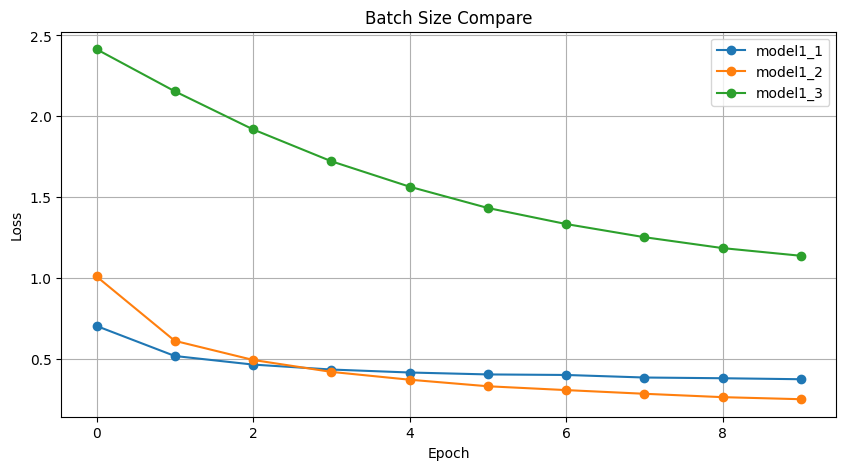


######################################################################
Learning Rate Compare
######################################################################
Model       : model2_1
Accuracy    : 96.86%
Total Params: 537,354
Time        : 91.92s
Final Loss  : 0.2603
Model       : model2_2
Accuracy    : 94.84%
Total Params: 537,354
Time        : 103.83s
Final Loss  : 0.2676
Model       : model2_3
Accuracy    : 78.52%
Total Params: 537,354
Time        : 98.32s
Final Loss  : 1.0711


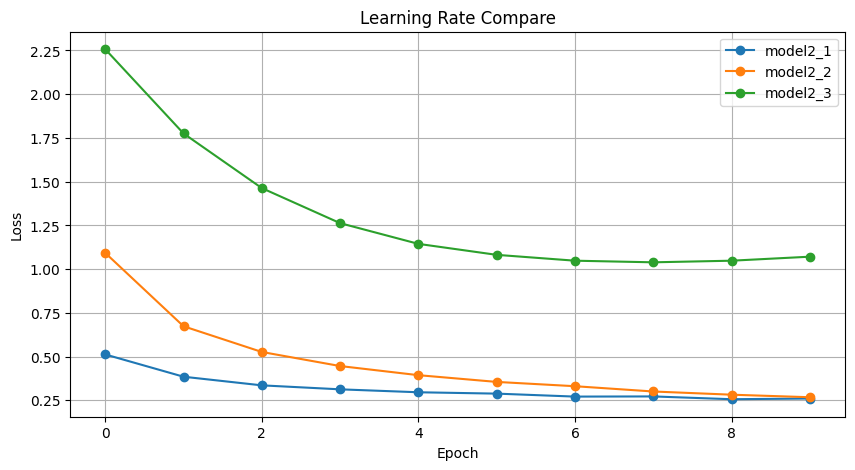

In [11]:
from training import evaluate
import matplotlib.pyplot as plt

groups = {
    "Batch Size Compare": [
        ("model1_1", model1_1, loss_history1_1, time1_1),
        ("model1_2", model1_2, loss_history1_2, time1_2),
        ("model1_3", model1_3, loss_history1_3, time1_3),
    ],
    "Learning Rate Compare": [
        ("model2_1", model2_1, loss_history2_1, time2_1),
        ("model2_2", model2_2, loss_history2_2, time2_2),
        ("model2_3", model2_3, loss_history2_3, time2_3),
    ],
    # "Dropout Compare": [
    #     ("model3_1", model3_1, loss_history3_1, time3_1),
    #     ("model3_2", model3_2, loss_history3_2, time3_2),
    # ],
    # "Optimizer Compare": [
    #     ("model4_1", model4_1, loss_history4_1, time4_1),
    #     ("model4_2", model4_2, loss_history4_2, time4_2),
    # ],
}

results = []

for group_name, experiments in groups.items():
    print("\n" + "#" * 70)
    print(group_name)
    print("#" * 70)

    for name, model, loss_history, sec in experiments:
        acc, n_params = evaluate(model, x_test, y_test)
        results.append((group_name, name, acc, n_params, sec, loss_history[-1]))

        print("=" * 60)
        print(f"Model       : {name}")
        print(f"Accuracy    : {acc:.2f}%")
        print(f"Total Params: {n_params:,}")
        print(f"Time        : {sec:.2f}s")
        print(f"Final Loss  : {loss_history[-1]:.4f}")

    plt.figure(figsize=(10, 5))

    for name, model, loss_history, sec in experiments:
        plt.plot(loss_history, marker="o", label=name)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(group_name)
    plt.legend()
    plt.grid(True)
    plt.show()